# 🍽️ Zomato Restaurant Data Analysis
##  Objective
This project analyzes Zomato restaurant data to understand the key factors influencing restaurant success and customer satisfaction.

##  Problem Statement
What makes a restaurant successful on Zomato?

We aim to analyze:
- Relationship between cost and ratings
- Impact of online ordering on ratings
- Popular restaurant types
- Customer behavior trends

##  Dataset Description
The dataset contains information about restaurants including:
- Restaurant name
- Ratings
- Cost for two people
- Online ordering availability
- Restaurant category/type

##  Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

##  Key Business Questions

1. Do higher-priced restaurants have better ratings?
2. Does online ordering improve customer satisfaction?
3. Which restaurant types are most popular?
4. What factors influence ratings the most?

##  Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
zomato = pd.read_csv("Zomato_data.csv")
zomato.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
zomato.dtypes

,0
name,object
online_order,object
book_table,object
rate,object
votes,int64
approx_cost(for two people),int64
listed_in(type),object


##  Data Cleaning

To ensure accurate analysis:
- Removed '/5' from ratings
- Converted ratings to numeric format
- Handled missing or invalid values

In [8]:
# Clean rating column
zomato['rate'] = zomato['rate'].astype(str).str.replace('/5', '', regex=False)

# Convert to numeric
zomato['float_ratings'] = pd.to_numeric(zomato['rate'], errors='coerce')

# Check result
zomato[['rate', 'float_ratings']].head()


,rate,float_ratings
0,4.1,4.1
1,4.1,4.1
2,3.8,3.8
3,3.7,3.7
4,3.8,3.8


##  Rating Distribution

This visualization shows how restaurant ratings are distributed across the dataset.

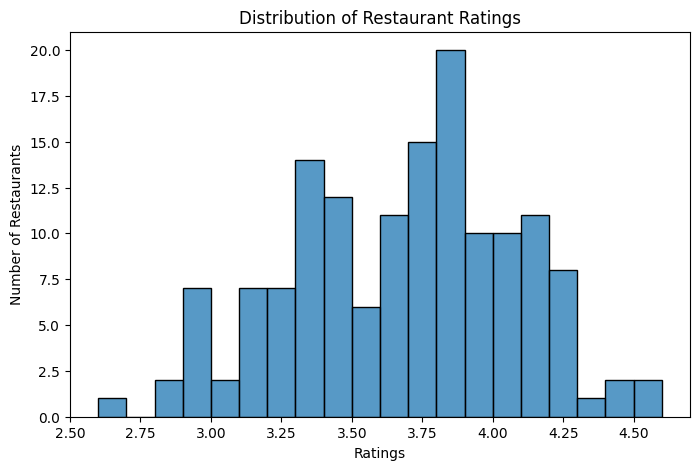

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(zomato['float_ratings'].dropna(), bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")

plt.show()

**Insight:**  
A majority of restaurants fall within the 3.5–4.5 rating range, indicating consistently positive customer feedback across the platform.

##  Correlation Analysis

This heatmap shows relationships between numerical variables in the dataset.

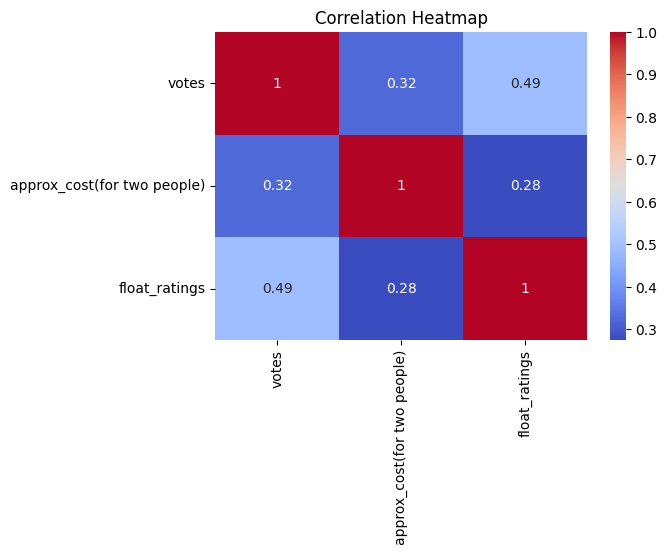

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(
    zomato.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Insight:**  
Ratings have weak correlation with cost, indicating that price is not a strong predictor of restaurant quality.

##  Cost vs Rating

This analysis explores whether higher-priced restaurants receive better ratings.

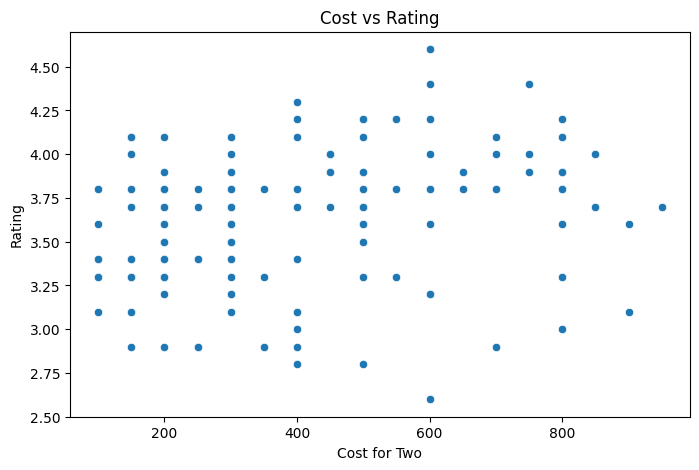

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='approx_cost(for two people)',
    y='float_ratings',
    data=zomato
)

plt.title("Cost vs Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.show()

**Insight:**  
Higher cost does not guarantee better ratings. Many mid-range restaurants perform equally well.

## 🏆 Top Rated Restaurants

In [15]:
top_restaurants = zomato.sort_values(by='float_ratings', ascending=False)

top_restaurants[['name', 'float_ratings']].head(10)

,name,float_ratings
7,Onesta,4.6
44,Onesta,4.6
38,Empire Restaurant,4.4
86,Meghana Foods,4.4
52,Corner House Ice Cream,4.3
57,Wamama,4.2
60,Peppy Peppers,4.2
81,Frozen Bottle,4.2
34,Faasos,4.2
12,The Coffee Shack,4.2


##  Online Ordering Impact

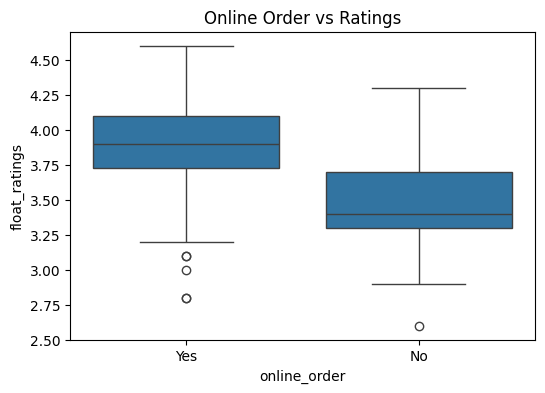

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='online_order', y='float_ratings', data=zomato)
plt.title("Online Order vs Ratings")
plt.show()

**Insight:**  
Restaurants offering online ordering tend to have slightly higher ratings.

##  Restaurant Type Distribution

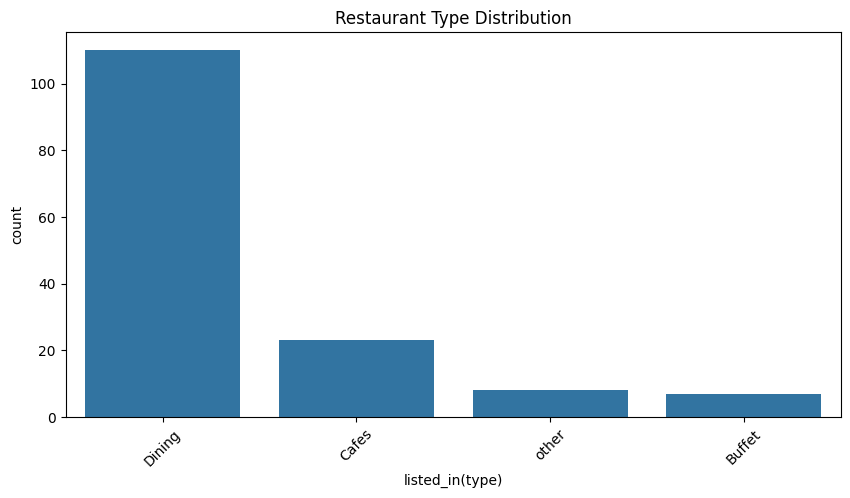

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=zomato,
    x='listed_in(type)',
    order=zomato['listed_in(type)'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Restaurant Type Distribution")
plt.show()

**Insight:**  
Casual dining and quick bites dominate the dataset.

## 📊 Dataset Overview

The dataset includes restaurant details such as ratings, cost, type, and online ordering availability.

Initial observations:
- Ratings mostly range between 3 and 5
- Wide variation in cost
- Multiple restaurant categories exist

##  Final Insights & Conclusion

Based on the analysis of the Zomato dataset, the following key insights were observed:

-  **Ratings Distribution:**  
  Most restaurants have ratings between **3.5 and 4.5**, indicating generally positive customer satisfaction.

-  **Cost vs Rating:**  
  There is no strong relationship between cost and ratings. Expensive restaurants do not necessarily provide better experiences.

-  **Online Ordering Impact:**  
  Restaurants offering online ordering tend to have slightly higher ratings, suggesting convenience improves customer satisfaction.

- 🍴 **Restaurant Type Trends:**  
  Casual dining and quick bites are the most common restaurant types, showing strong customer preference for affordable and fast options.

- 🔗 **Correlation Analysis:**  
  Ratings show weak correlation with cost, indicating that pricing is not a strong predictor of quality.

---

##  Final Takeaway

Restaurant success on Zomato is influenced more by **customer experience and convenience** rather than just pricing.

Features like **online ordering and service quality** play a significant role in improving ratings.

---

##  Future Improvements

- Build a machine learning model to predict restaurant ratings  
- Create an interactive dashboard using Streamlit  
- Perform location-based analysis for deeper insights  